# Test Quality Prediction Model - KNN & Random Forest

## Assignment Component: Quality Prediction for Test Cases

**Team Member:** Rashani K.G.M  

## 1. Introduction

This notebook implements **K-Nearest Neighbors (KNN)** and **Random Forest** algorithms to predict test case quality scores.

### Quality Categories:
- **Excellent** (80-100): High quality tests
- **Good** (60-79): Acceptable quality
- **Fair** (40-59): Needs improvement
- **Poor** (0-39): Requires major revision

## 2. Import Libraries and Load Data

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


In [23]:
# Load test quality dataset
df = pd.read_csv('component-4-quality/datasets/test_quality_data.csv')

# Create quality categories from quality_score
def categorize_quality(score):
    if score >= 80:
        return 'Excellent'
    elif score >= 60:
        return 'Good'
    elif score >= 40:
        return 'Fair'
    else:
        return 'Poor'

df['quality_category'] = df['quality_score'].apply(categorize_quality)

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'First 5 rows:')
df.head()

Dataset shape: (500, 16)
Columns: ['test_id', 'user_story_id', 'title', 'assertion_count', 'has_boundary_values', 'has_negative_test', 'step_count', 'has_error_handling', 'cyclomatic_complexity', 'has_setup_teardown', 'historical_pass_rate', 'quality_score', 'detected_bugs', 'framework', 'created_at', 'quality_category']
First 5 rows:


,test_id,user_story_id,title,assertion_count,has_boundary_values,has_negative_test,step_count,has_error_handling,cyclomatic_complexity,has_setup_teardown,historical_pass_rate,quality_score,detected_bugs,framework,created_at,quality_category
0,TEST_0000,US_089,Test case 0 for feature 36,15,True,False,15,True,5.66,False,0.768,88.45,1,cypress,2025-06-01T13:44:35.040570,Excellent
1,TEST_0001,US_059,Test case 1 for feature 2,14,False,True,3,False,1.08,False,0.692,82.65,1,selenium,2025-12-22T13:44:35.040589,Excellent
2,TEST_0002,US_051,Test case 2 for feature 45,13,False,False,13,False,8.36,False,0.963,61.11,0,cypress,2025-07-20T13:44:35.040597,Good
3,TEST_0003,US_026,Test case 3 for feature 49,1,True,True,19,True,4.75,True,0.507,74.26,1,selenium,2025-10-07T13:44:35.040603,Good
4,TEST_0004,US_031,Test case 4 for feature 15,10,True,False,8,False,4.95,False,0.666,73.22,1,playwright,2025-06-07T13:44:35.040608,Good


## 3. Data Preprocessing

In [24]:
# Display dataset statistics
print('Dataset Statistics:')
print(df.describe())

print(f'Quality Distribution:')
print(df['quality_category'].value_counts())

Dataset Statistics:
       assertion_count  step_count  cyclomatic_complexity  \
count       500.000000  500.000000             500.000000   
mean          7.938000   11.286000               5.521700   
std           4.409199    5.117478               2.529942   
min           1.000000    3.000000               1.010000   
25%           4.000000    7.000000               3.327500   
50%           8.000000   11.000000               5.650000   
75%          12.000000   16.000000               7.745000   
max          15.000000   20.000000               9.950000   

       historical_pass_rate  quality_score  detected_bugs  
count             500.00000     500.000000     500.000000  
mean                0.74468      77.426760       0.794000  
std                 0.14771      15.805604       0.404836  
min                 0.50000      26.290000       0.000000  
25%                 0.61850      66.087500       1.000000  
50%                 0.73850      78.625000       1.000000  
75%       

In [25]:
# Prepare features and target
feature_cols = ['assertion_count', 'has_boundary_values', 'has_negative_test',
                'step_count', 'has_error_handling', 'cyclomatic_complexity',
                'has_setup_teardown', 'historical_pass_rate']

X = df[feature_cols]
y = df['quality_category']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Quality categories: {y.unique()}')

Features shape: (500, 8)
Target shape: (500,)
Quality categories: <StringArray>
['Excellent', 'Good', 'Fair', 'Poor']
Length: 4, dtype: str


In [26]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')
print(f'Training distribution:')
print(y_train.value_counts())
print(f'Testing distribution:')
print(y_test.value_counts())

Training set: (400, 8)
Testing set: (100, 8)
Training distribution:
quality_category
Excellent    185
Good         157
Fair          54
Poor           4
Name: count, dtype: int64
Testing distribution:
quality_category
Excellent    46
Good         39
Fair         14
Poor          1
Name: count, dtype: int64


In [27]:
# Feature scaling (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Features scaled using StandardScaler')

Features scaled using StandardScaler


## 4. Visualize Quality Distribution

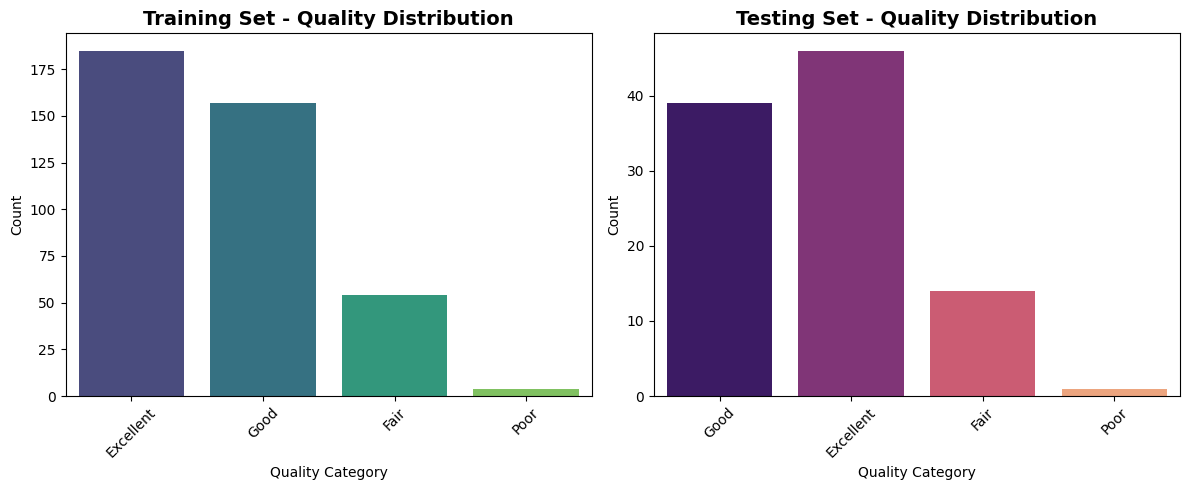

In [28]:
# Plot quality distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='viridis')
plt.title('Training Set - Quality Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Quality Category')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(x=y_test, palette='magma')
plt.title('Testing Set - Quality Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Quality Category')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 5. KNN Model - Finding Optimal K

In [29]:
# Test different K values
k_range = range(1, 31)
knn_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    knn_scores.append(accuracy)
    print(f'K={k}: Accuracy = {accuracy:.4f}')

# Find optimal K
optimal_k = k_range[np.argmax(knn_scores)]
best_knn_accuracy = max(knn_scores)
print(f'Optimal K value: {optimal_k}')
print(f'Best KNN accuracy: {best_knn_accuracy:.4f}')

K=1: Accuracy = 0.7800
K=2: Accuracy = 0.7800
K=3: Accuracy = 0.7500
K=4: Accuracy = 0.7200
K=5: Accuracy = 0.7300
K=6: Accuracy = 0.7100
K=7: Accuracy = 0.7300
K=8: Accuracy = 0.7200
K=9: Accuracy = 0.6900
K=10: Accuracy = 0.6600
K=11: Accuracy = 0.6700
K=12: Accuracy = 0.6400
K=13: Accuracy = 0.6700
K=14: Accuracy = 0.6700
K=15: Accuracy = 0.6500
K=16: Accuracy = 0.6700
K=17: Accuracy = 0.6600
K=18: Accuracy = 0.6400
K=19: Accuracy = 0.6600
K=20: Accuracy = 0.6700
K=21: Accuracy = 0.6800
K=22: Accuracy = 0.6600
K=23: Accuracy = 0.6500
K=24: Accuracy = 0.6400
K=25: Accuracy = 0.6500
K=26: Accuracy = 0.6600
K=27: Accuracy = 0.6700
K=28: Accuracy = 0.6700
K=29: Accuracy = 0.6800
K=30: Accuracy = 0.6700
Optimal K value: 1
Best KNN accuracy: 0.7800


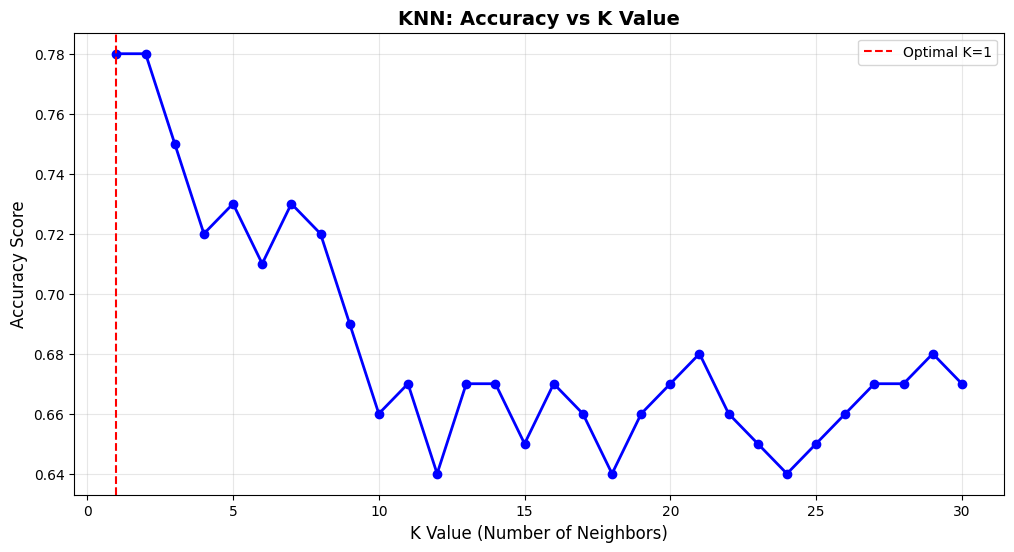

In [30]:
# Plot K vs Accuracy
plt.figure(figsize=(12, 6))
plt.plot(k_range, knn_scores, marker='o', linestyle='-', color='blue', linewidth=2)
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
plt.xlabel('K Value (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('KNN: Accuracy vs K Value', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Random Forest Model

In [31]:
# Test different number of trees
n_estimators_range = [10, 20, 50, 100, 150, 200]
rf_scores = []

for n_trees in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    rf.fit(X_train_scaled, y_train)
    y_pred = rf.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    rf_scores.append(accuracy)
    print(f'Trees={n_trees}: Accuracy = {accuracy:.4f}')

# Find optimal number of trees
optimal_trees = n_estimators_range[np.argmax(rf_scores)]
best_rf_accuracy = max(rf_scores)
print(f'Optimal trees: {optimal_trees}')
print(f'Best Random Forest accuracy: {best_rf_accuracy:.4f}')

Trees=10: Accuracy = 0.6600
Trees=20: Accuracy = 0.7200
Trees=50: Accuracy = 0.7300
Trees=100: Accuracy = 0.7600
Trees=150: Accuracy = 0.7600
Trees=200: Accuracy = 0.7600
Optimal trees: 100
Best Random Forest accuracy: 0.7600


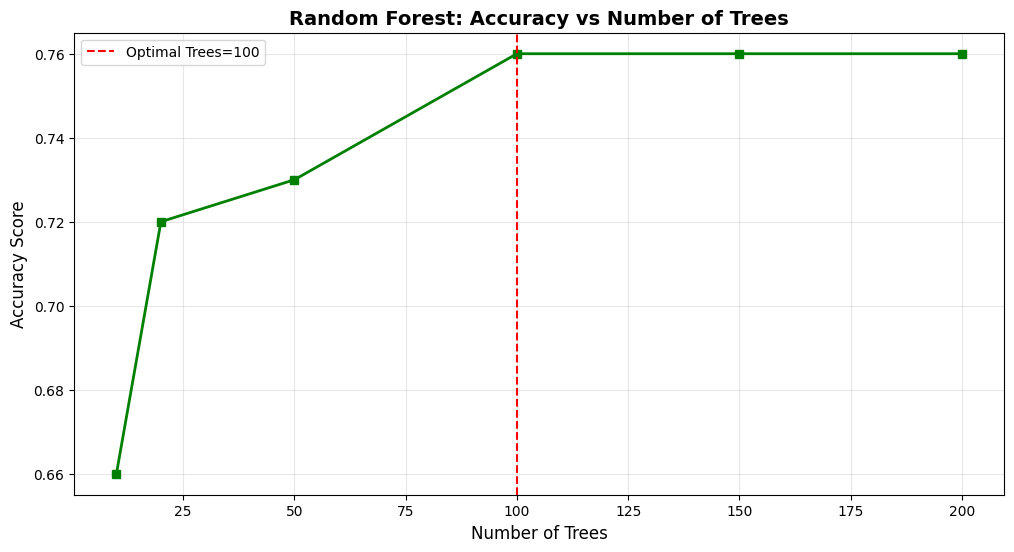

In [32]:
# Plot Trees vs Accuracy
plt.figure(figsize=(12, 6))
plt.plot(n_estimators_range, rf_scores, marker='s', linestyle='-', color='green', linewidth=2)
plt.axvline(x=optimal_trees, color='red', linestyle='--', label=f'Optimal Trees={optimal_trees}')
plt.xlabel('Number of Trees', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Random Forest: Accuracy vs Number of Trees', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 7. Train Final Models

In [33]:
# Train final KNN model
knn_final = KNeighborsClassifier(n_neighbors=optimal_k)
knn_final.fit(X_train_scaled, y_train)
knn_predictions = knn_final.predict(X_test_scaled)

print(f'KNN Model trained with K={optimal_k}')

# Train final Random Forest model
rf_final = RandomForestClassifier(n_estimators=optimal_trees, random_state=42)
rf_final.fit(X_train_scaled, y_train)
rf_predictions = rf_final.predict(X_test_scaled)

print(f'Random Forest Model trained with {optimal_trees} trees')

KNN Model trained with K=1
Random Forest Model trained with 100 trees


## 8. Model Evaluation

K-NEAREST NEIGHBORS (KNN) MODEL
Accuracy: 0.7800 (78.00%)
Classification Report:
              precision    recall  f1-score   support

   Excellent       0.81      0.96      0.88        46
        Fair       0.75      0.43      0.55        14
        Good       0.73      0.69      0.71        39
        Poor       1.00      1.00      1.00         1

    accuracy                           0.78       100
   macro avg       0.82      0.77      0.78       100
weighted avg       0.77      0.78      0.77       100



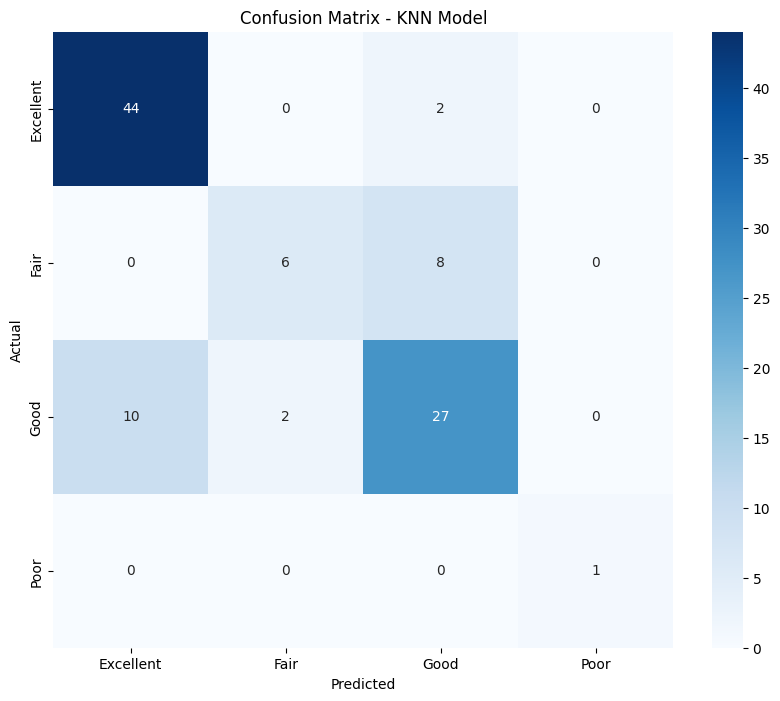

In [34]:
# Evaluate KNN
knn_accuracy = accuracy_score(y_test, knn_predictions)
print('='*60)
print('K-NEAREST NEIGHBORS (KNN) MODEL')
print('='*60)
print(f'Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)')
print(f'Classification Report:')
print(classification_report(y_test, knn_predictions))

# Confusion Matrix for KNN
cm_knn = confusion_matrix(y_test, knn_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Excellent', 'Fair', 'Good', 'Poor'],
            yticklabels=['Excellent', 'Fair', 'Good', 'Poor'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN Model')
plt.show()

RANDOM FOREST MODEL
Accuracy: 0.7600 (76.00%)
Classification Report:
              precision    recall  f1-score   support

   Excellent       0.80      0.93      0.86        46
        Fair       0.83      0.36      0.50        14
        Good       0.70      0.72      0.71        39
        Poor       0.00      0.00      0.00         1

    accuracy                           0.76       100
   macro avg       0.58      0.50      0.52       100
weighted avg       0.76      0.76      0.74       100



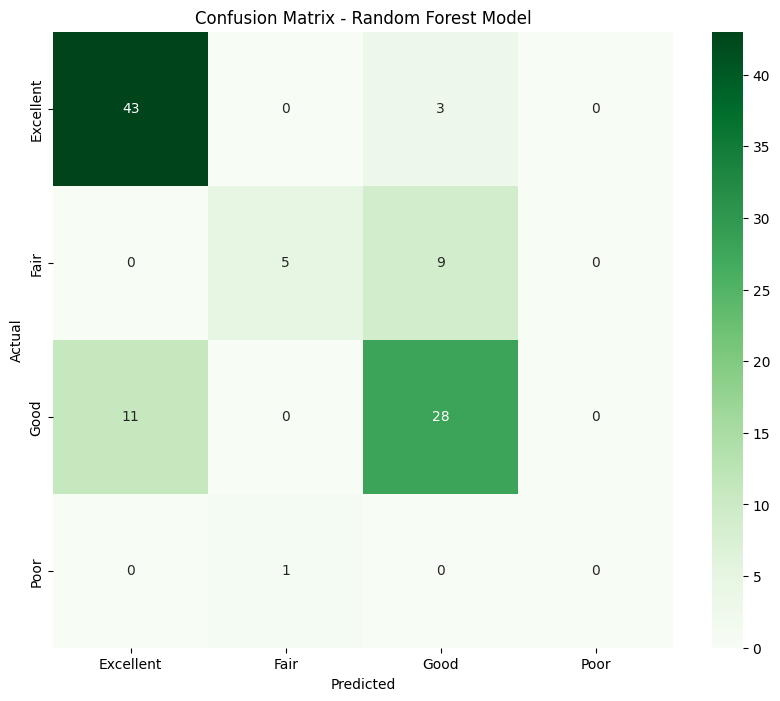

In [35]:
# Evaluate Random Forest
rf_accuracy = accuracy_score(y_test, rf_predictions)
print('='*60)
print('RANDOM FOREST MODEL')
print('='*60)
print(f'Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)')
print(f'Classification Report:')
print(classification_report(y_test, rf_predictions))

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, rf_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Excellent', 'Fair', 'Good', 'Poor'],
            yticklabels=['Excellent', 'Fair', 'Good', 'Poor'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Model')
plt.show()

# Compare models
models = ['KNN', 'Random Forest']
accuracies = [knn_accuracy, rf_accuracy]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['blue', 'green'], edgecolor='black', linewidth=1.5)
plt.ylim(0, 1)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Comparison: KNN vs Random Forest', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc*100:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.show()

# Select best model
if knn_accuracy >= rf_accuracy:
    best_model = knn_final
    best_model_name = 'KNN'
    best_accuracy = knn_accuracy
else:
    best_model = rf_final
    best_model_name = 'Random Forest'
    best_accuracy = rf_accuracy

print(f'Best Model: {best_model_name}')
print(f'Best Accuracy: {best_accuracy*100:.2f}%')

Cross-Validation Results:
KNN:
  Scores: [0.625  0.6875 0.7125 0.7375 0.75  ]
  Mean: 0.7025 (+/- 0.0886)
Random Forest:
  Scores: [0.8125 0.7625 0.75   0.7625 0.8125]
  Mean: 0.7800 (+/- 0.0539)


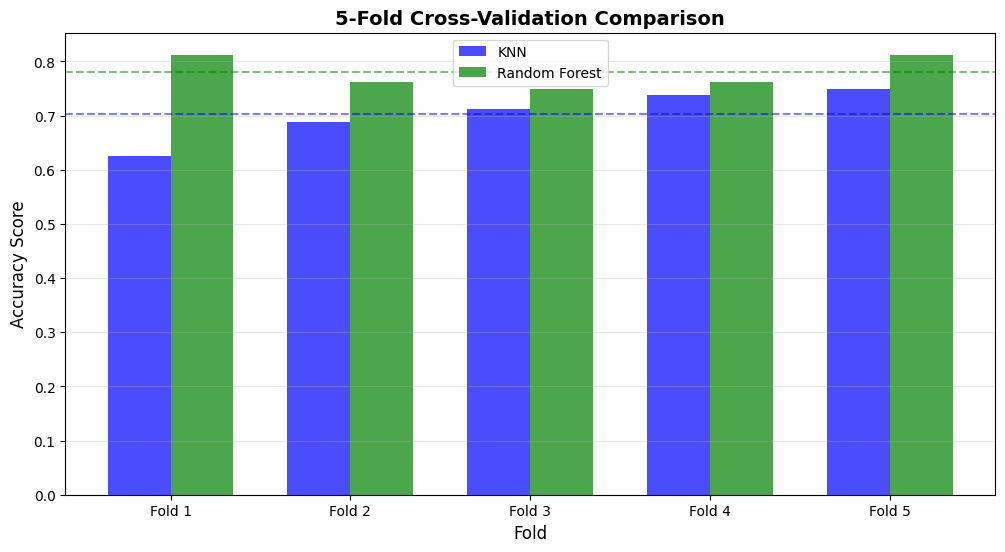

In [36]:
# 5-fold cross-validation for both models
cv_knn = cross_val_score(knn_final, X_train_scaled, y_train, cv=5)
cv_rf = cross_val_score(rf_final, X_train_scaled, y_train, cv=5)

print('Cross-Validation Results:')
print(f'KNN:')
print(f'  Scores: {cv_knn}')
print(f'  Mean: {cv_knn.mean():.4f} (+/- {cv_knn.std() * 2:.4f})')
print(f'Random Forest:')
print(f'  Scores: {cv_rf}')
print(f'  Mean: {cv_rf.mean():.4f} (+/- {cv_rf.std() * 2:.4f})')

# Visualize CV scores
plt.figure(figsize=(12, 6))
x = np.arange(1, 6)
width = 0.35
plt.bar(x - width/2, cv_knn, width, label='KNN', color='blue', alpha=0.7)
plt.bar(x + width/2, cv_rf, width, label='Random Forest', color='green', alpha=0.7)
plt.axhline(y=cv_knn.mean(), color='blue', linestyle='--', alpha=0.5)
plt.axhline(y=cv_rf.mean(), color='green', linestyle='--', alpha=0.5)
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('5-Fold Cross-Validation Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, [f'Fold {i}' for i in range(1, 6)])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 10. Cross-Validation

Feature Importance:
                 feature  importance
0        assertion_count    0.203576
7   historical_pass_rate    0.166111
3             step_count    0.150647
5  cyclomatic_complexity    0.146045
4     has_error_handling    0.117911
1    has_boundary_values    0.105504
2      has_negative_test    0.065258
6     has_setup_teardown    0.044948


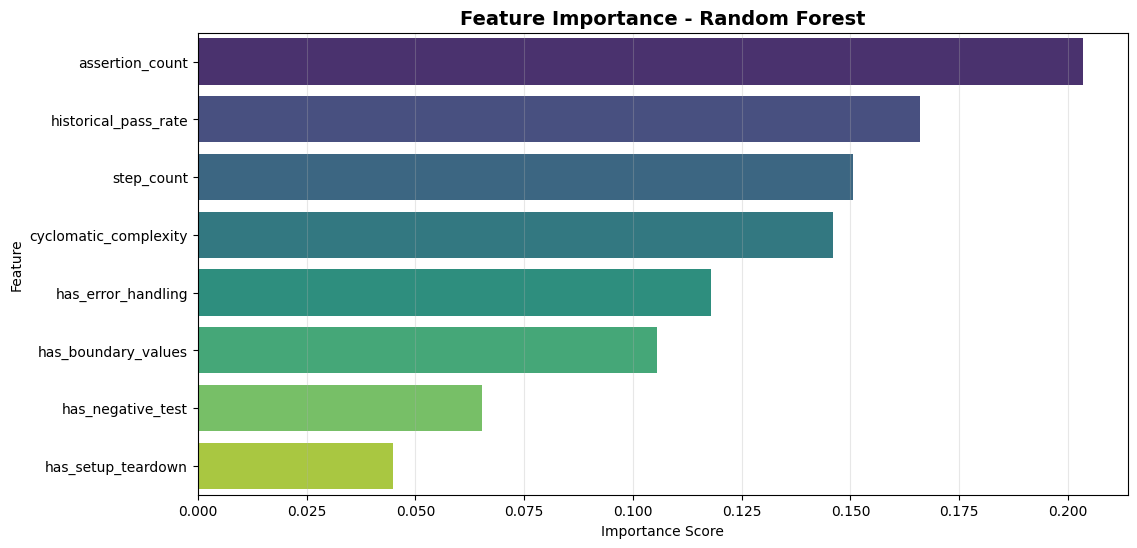

In [37]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False)

print('Feature Importance:')
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.show()

# Test with sample data
sample_test = pd.DataFrame({
    'assertion_count': [5, 2, 8, 3],
    'has_boundary_values': [1, 0, 1, 0],
    'has_negative_test': [1, 0, 1, 1],
    'step_count': [8, 4, 12, 5],
    'has_error_handling': [1, 0, 1, 0],
    'cyclomatic_complexity': [4.5, 7.0, 3.2, 8.5],
    'has_setup_teardown': [1, 0, 1, 0],
    'historical_pass_rate': [0.85, 0.45, 0.92, 0.35]
})

sample_scaled = scaler.transform(sample_test)

# Predictions
knn_preds = best_model.predict(sample_scaled)
rf_preds = rf_final.predict(sample_scaled)

results = pd.DataFrame({
    'Test Case': [f'Test_{i+1}' for i in range(4)],
    'Assertions': sample_test['assertion_count'],
    'Steps': sample_test['step_count'],
    'KNN Prediction': knn_preds,
    'RF Prediction': rf_preds
})

print('Sample Predictions:')
print(results)

In [38]:
# Feature importance from Random Forestfeature_importance = pd.DataFrame({    'feature': feature_cols,    'importance': rf_final.feature_importances_}).sort_values('importance', ascending=False)print('Feature Importance:')print(feature_importance)# Plot feature importanceplt.figure(figsize=(12, 6))sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')plt.xlabel('Importance Score')plt.ylabel('Feature')plt.grid(axis='x', alpha=0.3)plt.show()

# Save the best model
import os
os.makedirs('component-4-quality/saved_models', exist_ok=True)

model_path = f'component-4-quality/saved_models/quality_scorer.pkl'
joblib.dump(best_model, model_path)
print(f'Best model ({best_model_name}) saved to {model_path}')

# Save scaler
scaler_path = f'component-4-quality/saved_models/feature_scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f'Scaler saved to {scaler_path}')

# Save feature columns
import json
features_path = f'component-4-quality/saved_models/feature_columns.json'
with open(features_path, 'w') as f:
    json.dump(feature_cols, f)
print(f'Feature columns saved to {features_path}')

In [ ]:
# Test with sample datasample_test = pd.DataFrame({    'assertion_count': [5, 2, 8, 3],    'has_boundary_values': [1, 0, 1, 0],    'has_negative_test': [1, 0, 1, 1],    'step_count': [8, 4, 12, 5],    'has_error_handling': [1, 0, 1, 0],    'cyclomatic_complexity': [4.5, 7.0, 3.2, 8.5],    'has_setup_teardown': [1, 0, 1, 0],    'historical_pass_rate': [0.85, 0.45, 0.92, 0.35]})sample_scaled = scaler.transform(sample_test)# Predictionsknn_preds = best_model.predict(sample_scaled)rf_preds = rf_final.predict(sample_scaled)results = pd.DataFrame({    'Test Case': [f'Test_{i+1}' for i in range(4)],    'Assertions': sample_test['assertion_count'],    'Steps': sample_test['step_count'],    'KNN Prediction': knn_preds,    'RF Prediction': rf_preds})print('Sample Predictions:')print(results)

print('
' + '='*60)
print('FINAL MODEL SUMMARY')
print('='*60)
print(f'Best Model: {best_model_name}')
print(f'Test Accuracy: {best_accuracy*100:.2f}%')
if best_model_name == 'KNN':
    print(f'K Value: {optimal_k}')
    print(f'CV Accuracy: {cv_knn.mean()*100:.2f}%')
else:
    print(f'Number of Trees: {optimal_trees}')
    print(f'CV Accuracy: {cv_rf.mean()*100:.2f}%')
print(f'Quality Categories: Excellent, Good, Fair, Poor')
print(f'Features Used: {len(feature_cols)}')
print(f'Training Samples: {len(X_train)}')
print(f'Testing Samples: {len(X_test)}')
print('='*60)
print('MODEL TRAINING COMPLETED SUCCESSFULLY!')

In [ ]:
# Save the best modelimport osos.makedirs('component-4-quality/saved_models', exist_ok=True)model_path = f'component-4-quality/saved_models/quality_scorer.pkl'joblib.dump(best_model, model_path)print(f'Best model ({best_model_name}) saved to {model_path}')# Save scalerscaler_path = f'component-4-quality/saved_models/feature_scaler.pkl'joblib.dump(scaler, scaler_path)print(f'Scaler saved to {scaler_path}')# Save feature columnsimport jsonfeatures_path = f'component-4-quality/saved_models/feature_columns.json'with open(features_path, 'w') as f:    json.dump(feature_cols, f)print(f'Feature columns saved to {features_path}')